## Harringtonine - interpretation

___

In [ ]:
import sys; from pathlib import Path
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.extend([str(src_dir), str(src_dir / 'pipelines')])
main_dir = Path(src_dir.parents[0])
from imports import * 
from tasep_models import *
from numba import njit
import hashlib
current_dir = Path().resolve() 

In [ ]:
@njit
def numba_seed(seed):
    np.random.seed(seed)

REPRODUCIBLE_RANDOM_SEED = 42
REPRODUCIBLE_N_JOBS = -1

def stable_seed(*parts):
    """Create a deterministic uint32 seed from notebook/script-stable values."""
    key = "|".join(str(part) for part in parts).encode("utf-8")
    return int.from_bytes(hashlib.blake2b(key, digest_size=4).digest(), "little")

def seed_all_rngs(seed):
    """Seed Python, NumPy, and Numba RNGs from the same deterministic seed."""
    seed = int(seed) % (2**32 - 1)
    random.seed(seed)
    np.random.seed(seed)
    numba_seed(seed)
    return seed

def _build_tasep_rate_vector(ki, ke, gene_length, pause_location=None, pause_elongation_rate=None):
    if isinstance(ke, (int, float)):
        k_elongation = np.full(gene_length - 2, ke, dtype=np.float64)
    else:
        k_elongation = np.asarray(ke, dtype=np.float64)
    k_termination = k_elongation[-1]
    k_full = np.concatenate(([ki], k_elongation, [k_termination])).astype(np.float64)
    if pause_location is not None and pause_elongation_rate is not None:
        if 0 <= pause_location < gene_length:
            k_full[pause_location] = pause_elongation_rate
        else:
            raise ValueError("pause_location must be within the range of gene_length.")
    return k_full

def _run_seeded_fast_tasep(args):
    seed, tasep_args = args
    seed_all_rngs(seed)
    return TASEP_SSA(*tasep_args)

def simulate_TASEP_SSA_seeded_fast(ki, ke, gene_length, t_max, time_interval_in_seconds=1,
                                   number_repetitions=1, first_probe_position_vector=None,
                                   timePerturbationApplication=0, evaluatingInhibitor=0,
                                   evaluatingFRAP=0, n_jobs=-1, burnin_time=0,
                                   inhibitor_effectiveness=0, constant_elongation_rate=None,
                                   pause_location=None, pause_elongation_rate=None,
                                   fast_output=True, batch_size='auto',
                                   random_seed=REPRODUCIBLE_RANDOM_SEED,
                                   seed_context="tasep"):
    """Deterministic parallel fast-output SSA wrapper.

    Each repetition gets its own stable seed inside the joblib worker, so results are
    independent of worker count and process scheduling.
    """
    if not fast_output:
        raise ValueError("simulate_TASEP_SSA_seeded_fast supports fast_output=True only.")

    if burnin_time > 0:
        timePerturbationApplication = (timePerturbationApplication or 0) + burnin_time
        t_max += burnin_time

    t_array = np.arange(0, t_max, time_interval_in_seconds, dtype=np.float64)
    k_full = _build_tasep_rate_vector(ki, ke, gene_length, pause_location, pause_elongation_rate)
    if first_probe_position_vector is None:
        first_probe_position_vector = np.empty(0, dtype=np.float64)
    else:
        first_probe_position_vector = np.asarray(first_probe_position_vector, dtype=np.float64)

    constant_rate = constant_elongation_rate if constant_elongation_rate is not None else -1.0
    tasep_args = (k_full, t_array, timePerturbationApplication, int(evaluatingInhibitor),
                  int(evaluatingFRAP), inhibitor_effectiveness, constant_rate,
                  True, first_probe_position_vector)
    args_list = [
        (stable_seed(random_seed, seed_context, rep), tasep_args)
        for rep in range(number_repetitions)
    ]

    list_first_signal = Parallel(n_jobs=n_jobs, batch_size=batch_size)(
        delayed(_run_seeded_fast_tasep)(args) for args in args_list
    )
    matrix_intensity_first_signal_RT = np.asarray(list_first_signal)

    if burnin_time > 0:
        idx_burnin = int(burnin_time / time_interval_in_seconds)
        matrix_intensity_first_signal_RT = matrix_intensity_first_signal_RT[:, idx_burnin:]

    return (None, None, matrix_intensity_first_signal_RT, None)

In [3]:
results_folder = Path('/Users/nzlab-la/Desktop/utag_paper/optimization/results_ACF/')
results_HT_data = Path ('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Raw_Data_ACF_HT')

results_HT_plots = Path('notebooks/Figure_6/HT_plots')
results_HT_plots.mkdir(parents=True, exist_ok=True)

In [4]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
})

In [5]:
def extract_params(filename):
    df = pd.read_csv(results_folder / filename)
    ki_value = df[df['parameter'] == 'ki']['value'].iloc[0]
    ke_value = df[df['parameter'] == 'ke']['value'].iloc[0]
    return float(ke_value), float(ki_value)

In [6]:
def model_and_data_selection(dataset):
    if dataset == 'utag':
        tag_sequence = tag_dict['U']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna' )
        ke_utag, ki_utag = extract_params('optimized_params_utag.csv')
        list_param = [ki_utag, ke_utag, 'utag']
    elif dataset == 'utag_c_free':
        tag_sequence = tag_dict['U']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna' )
        ke_utag_c_free, ki_utag_c_free = extract_params('optimized_params_utag_c_free.csv')
        list_param = [ki_utag_c_free, ke_utag_c_free, 'utag_c_free']
    elif dataset == 'suntag':
        tag_sequence = tag_dict['SUN']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ266(pUB-24xGCN4-KDM5B-MS2).dna' )
        ke_suntag, ki_suntag = extract_params('optimized_params_suntag.csv')
        list_param = [ki_suntag, ke_suntag, 'suntag']
    elif dataset == 'alfatag':
        tag_sequence = tag_dict['ALFA']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ267 (pUB-24xALFAtag-KDM5B-MS2).dna' )
        ke_alfatag, ki_alfatag = extract_params('optimized_params_alfatag.csv')
        list_param = [ki_alfatag, ke_alfatag, 'alfatag']
    # reading the gene sequence
    protein, rna, dna, indexes_tags, _, seq_record, graphic_features  = read_sequence(seq=dna_file_path, min_protein_length=50,TAG=[tag_sequence])
    gene_length = len(protein)+1 # adding 1 to account for the stop codon
    tag_positions_first_probe_vector = indexes_tags[0]
    first_probe_position_vector = create_probe_vector(tag_positions_first_probe_vector, gene_length)
    return list_param[2], rna, first_probe_position_vector, gene_length, list_param

In [7]:
def calculate_intensity( particle_counts_per_frame, sum_intensities_per_frame, harringtonine_frame):
    """
    Implement Equation from the paper for Harringtonine intensity calculation.
    
    For t < t_H: I(t) = (1/n_pre(t)) * sum(I_i(t))
    For t ≥ t_H: I(t) = (1/⟨n_pre⟩) * sum(I_i(t))
    
    Then normalize by mean intensity before treatment.
    """
    # Compute the average particle count before treatment (⟨n_pre⟩)
    pre_counts = particle_counts_per_frame[:harringtonine_frame]
    average_particles_before_treatment = pre_counts.mean()
    
    # For frames before treatment: I(t) = sum_intensities / n_pre(t)
    pre_intensities = sum_intensities_per_frame[:harringtonine_frame]
    intensity_before_treatment = np.where(pre_counts == 0, 0, pre_intensities / pre_counts)
    
    # For frames after treatment: I(t) = sum_intensities / ⟨n_pre⟩
    post_intensities = sum_intensities_per_frame[harringtonine_frame:]
    if average_particles_before_treatment == 0:
        intensity_after_treatment = np.zeros_like(post_intensities)
    else:
        intensity_after_treatment = post_intensities / average_particles_before_treatment
    
    # Combine the two segments (this is I(t) from the equation)
    average_intensity_with_respect_number_particles = np.concatenate([
        intensity_before_treatment, 
        intensity_after_treatment
    ])
    
    # CORRECTED: Calculate mean from the RAW intensity before treatment
    mean_before_treatment = intensity_before_treatment.mean()
    
    # Second normalization: divide by mean intensity before treatment
    if mean_before_treatment == 0:
        intensities_normalized_before_treatment_intensity = np.zeros_like(average_intensity_with_respect_number_particles)
    else:
        intensities_normalized_before_treatment_intensity = average_intensity_with_respect_number_particles / mean_before_treatment

    return intensities_normalized_before_treatment_intensity, average_intensity_with_respect_number_particles, average_particles_before_treatment

In [8]:
def plot_harringtonine(results_folder,plot_name,responding_indices,full_frames,intensities_normalized,list_param,
        time_array_min,mean_intensity_ssa_ht,err_intensity_ssa_ht, use_sem=True,show_individual_trajectories=True, 
        color_sim='red', color_exp='blue',fig_size=(6, 2.5), show_linear_fit=True):
        
    show_runoff_time = True
    fig, ax = plt.subplots(figsize=fig_size, facecolor='white')
    ax.set_facecolor('white')
    
    # Plot responding trajectories in dimgray
    if show_individual_trajectories:
        for i in responding_indices:
            ax.plot(full_frames, intensities_normalized[i],
                    linestyle='-', color='dimgray', linewidth=0.2)

    # Calculate and plot the mean trajectory for responding trajectories only
    if responding_indices:  # check if the list is not empty
        mean_trajectory = np.mean(intensities_normalized[responding_indices, :], axis=0)
        std_trajectory = np.std(intensities_normalized[responding_indices, :], axis=0)
        if use_sem:
            err_trajectory = std_trajectory / np.sqrt(len(responding_indices))
        else:
            err_trajectory = std_trajectory
    
    # Plot the mean trajectory
    line_mean, = ax.plot(full_frames, mean_trajectory, 'o-',
                        color=color_exp, linewidth=1, label='Experimental', markersize=7)
    
    # Plot error bars
    ax.fill_between(full_frames,
                    mean_trajectory - err_trajectory,
                    mean_trajectory + err_trajectory,
                    color=color_exp, alpha=0.07)
    
    legend_label_sim = 'Model Validation'


    # DEFINE THE PARAMETERS FOR THE PLATEAU
    N = 15  # number of time points to average at the end
    threshold_value = 0.3 

    # Plotting the model
    plt.plot(time_array_min-5, mean_intensity_ssa_ht,'-',  color=color_sim, linewidth=3, label=legend_label_sim)
    plt.fill_between(time_array_min-5, mean_intensity_ssa_ht - err_intensity_ssa_ht,
                    mean_intensity_ssa_ht + err_intensity_ssa_ht, color=color_sim, alpha=0.1)

    # Plot the harringtonine frame as a vertical line (at x=0)
    #ax.axvline(x=0, color='black', linestyle='--', linewidth=1,) # label='Harringtonine')

    # Find simulation plateau time (similar to experimental)
    plateau_value_ssa = np.mean(mean_intensity_ssa_ht[-N:])
    threshold_ssa = threshold_value * plateau_value_ssa
    plateau_index_ssa = None
    for idx in range(len(mean_intensity_ssa_ht)):
        if abs(mean_intensity_ssa_ht[idx] - plateau_value_ssa) <= (threshold_ssa):
            plateau_index_ssa = idx
            break

    # FIND PLATEAU TIME FIRST (needed for linear fit range)
    plateau_value = np.mean(mean_trajectory[-N:])
    threshold = threshold_value * plateau_value
    
    plateau_index = None
    if show_runoff_time:
        for idx in range(len(mean_trajectory)):
            if abs(mean_trajectory[idx] - plateau_value) <= threshold:
                plateau_index = idx
                break
    
    plateau_time = None
    if plateau_index is not None:
        plateau_time = full_frames[plateau_index]

    # LINEAR FIT FROM HARRINGTONINE TO PLATEAU TIME
    if show_linear_fit and plateau_time is not None:
        # Find data points from harringtonine (x >= 0) to plateau time
        fit_mask = (full_frames >= 0) & (full_frames <= plateau_time)
        x_fit_range = full_frames[fit_mask]
        y_fit_range = mean_trajectory[fit_mask]
        
        # Remove any NaN or infinite values
        valid_mask = np.isfinite(x_fit_range) & np.isfinite(y_fit_range)
        x_fit = x_fit_range[valid_mask]
        y_fit = y_fit_range[valid_mask]
        
        if len(x_fit) > 1:  # Need at least 2 points for linear fit
            # Perform linear regression
            slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
            
            # Calculate run-off time (when linear fit crosses y=0)
            if slope != 0:
                runoff_time = -intercept / slope
                
                # Create extended x range for plotting the fit line from harringtonine to runoff
                if runoff_time > 0:
                    x_extended = np.linspace(0, runoff_time, 100)
                else:
                    # If runoff time is negative or zero, just plot to plateau
                    x_extended = np.linspace(0, plateau_time * 1.1, 100)
                    runoff_time = None
                
                y_fit_line = slope * x_extended + intercept
                
                
                # Mark the run-off time if it's reasonable
                if runoff_time is not None and runoff_time > 0 and runoff_time < 40:
                    print(f"\n--- Linear Fit Results for {plot_name} ---")
                    print(f"Fit range: {x_fit[0]:.1f} to {x_fit[-1]:.1f} min (HT to plateau)")
                    print(f"Slope: {slope:.4f} ± {std_err:.4f}")
                    print(f"Intercept: {intercept:.4f}")
                    print(f"R-squared: {r_value**2:.3f}")
                    print(f"P-value: {p_value:.2e}")
                    print(f"Run-off time: {runoff_time:.1f} min")
                else:
                    print(f"\n--- Linear Fit Results for {plot_name} ---")
                    print(f"Fit range: {x_fit[0]:.1f} to {x_fit[-1]:.1f} min (HT to plateau)")
                    print(f"Slope: {slope:.4f} ± {std_err:.4f}")
                    print(f"Intercept: {intercept:.4f}")
                    print(f"R-squared: {r_value**2:.3f}")
                    print(f"P-value: {p_value:.2e}")
                    print(f"Run-off time: Not within reasonable range")
                
            else:
                print(f"Warning: Linear fit has zero slope for {plot_name}")
        else:
            print(f"Warning: Not enough data points for linear fit in {plot_name}")
    
    elif show_linear_fit and plateau_time is None:
        print(f"Warning: Could not determine plateau time for {plot_name}, skipping linear fit")
    
    # Styling
    ax.set_xlabel("Time (min)", fontdict={'size': 16})
    ax.set_ylabel("Norm. Intensity", fontdict={'size': 16})
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Set spines color to black
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.5)
    
    plt.ylim(0, 1.4)
    plt.xlim(-5.5, 25)
    plt.tight_layout()
    ax.legend(fontsize=10, frameon=False, loc='upper right')

    # Save plots
    plt.savefig(results_folder.joinpath('HT_'+plot_name+'.png'), dpi=600)
    plt.savefig(results_folder.joinpath('HT_'+plot_name+'.svg'), dpi=600)
    print(f"Plots saved to: {results_folder}")

    plt.show()

In [9]:
def process_HT_data(processed_data,results_folder,harringtonine_frame,max_frame=30, plot_all_images= False,use_sem = True, show_individual_trajectories = False,show_summary= True,color_sim='red',RESPONSE_THRESHOLD=0.1, color_exp='blue',fig_size=(6, 2.5)):
    #RESPONSE_THRESHOLD = 0.8 # 20% of the baseline
    if processed_data == 'utag':
        results_dir = results_HT_data.joinpath('HT/Utag/HT_Analysis_GUI')
        plot_name = 'UTag'
    elif processed_data == 'suntag':
        results_dir = results_HT_data.joinpath('HT/Suntag/HT_Analysis_GUI')
        plot_name = 'SunTag'
    elif processed_data == 'alfatag':
        results_dir = results_HT_data.joinpath('HT/ALFAtag/HT_Analysis_GUI')
        plot_name = 'AlfaTag'
    elif processed_data == 'utag_c_free':
        results_dir = results_HT_data.joinpath('HT/UTag_CF/HT_Analysis_GUI')
        plot_name = 'utag_c_free'
    
    # results_folder is a subfolder in current working directory called temp
    #results_folder = Path(current_dir).joinpath('results_HT')
    #results_folder.mkdir(exist_ok=True)
    list_dataframes = []
    subfolders = [folder for folder in results_dir.iterdir() if folder.is_dir()]
    subfolders = [folder for folder in subfolders if 'results_' in folder.name]
    for subfolder in subfolders:
        files = [f for f in subfolder.iterdir() if f.is_file() and 'tracking_' in f.name and f.suffix == '.csv']
        dfs = pd.read_csv(files[0])
        list_dataframes.append(dfs)
    if plot_all_images == True:
        list_images = []
        for subfolder in subfolders:
            files = [f for f in subfolder.iterdir() if f.is_file() and 'tracking_' in f.name and f.suffix == '.png']
            image = [Image.open(f) for f in files][0]
            image = np.array(image)
            list_images.append(image)
        num_cols = 10
        num_rows = int(np.ceil(len(list_images) / num_cols))
        fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 8))
        # plot the images in the grid
        for i, image in enumerate(list_images):
            ax = axs[i // num_cols, i % num_cols]
            ax.imshow(image)
            ax.axis('off')
        for j in range(i + 1, num_rows * num_cols):
            ax = axs[j // num_cols, j % num_cols]
            ax.axis('off')
        fig.suptitle(f'{plot_name} Harringtonine cells', fontsize=20)
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
    full_frames = np.arange(0, max_frame) 
    array_particles = np.zeros((len(list_dataframes), len(full_frames)))
    average_intensity = np.zeros((len(list_dataframes), len(full_frames)))
    intensities_normalized = np.zeros((len(list_dataframes), len(full_frames)))
    average_molecules_before_treatment = np.zeros(len(list_dataframes))
    for i, df in enumerate(list_dataframes):
        # Group by 'frame' and count unique particles
        particle_counts_per_frame = df.groupby('frame')['particle'].nunique()
        sum_intensities_per_frame = df.groupby('frame')['spot_int_ch_0'].sum()
        # Re-index to include frames with no particles (fill missing with 0)
        particle_counts_per_frame = particle_counts_per_frame.reindex(full_frames, fill_value=0).values
        sum_intensities_per_frame = sum_intensities_per_frame.reindex(full_frames, fill_value=0).values
        # Ensure the lengths match the max frame
        if len(particle_counts_per_frame) > max_frame:
            particle_counts_per_frame = particle_counts_per_frame[:max_frame]
            sum_intensities_per_frame = sum_intensities_per_frame[:max_frame]
        # Normalize the intensities
        intensities_normalized_before_treatment_intensity, average_intensity_with_respect_number_particles,average_particles_before_treatment = calculate_intensity(particle_counts_per_frame, sum_intensities_per_frame, harringtonine_frame)
        # Store in array
        array_particles[i] = particle_counts_per_frame
        average_intensity[i] = average_intensity_with_respect_number_particles
        intensities_normalized[i] = intensities_normalized_before_treatment_intensity
        average_molecules_before_treatment[i] = average_particles_before_treatment

    treatment_start_index = harringtonine_frame #np.argmin(np.abs(full_frames - harringtonine_frame))
    non_responding_indices = []  # average post-treatment is not decreasing below the threshold
    responding_indices = []
    # Classify each trajectory
    for i, trajectory in enumerate(intensities_normalized):
        baseline = np.mean(trajectory[:treatment_start_index])
        threshold = RESPONSE_THRESHOLD * baseline
        #avg_post_treatment = np.mean(trajectory[treatment_start_index:])
        # the last 10 frames 
        avg_post_treatment = np.mean(trajectory[-5:])
        if avg_post_treatment >= threshold:
            non_responding_indices.append(i)
        else:
            responding_indices.append(i)
    if show_summary:
        # report percentage of non-responding trajectories
        print('---------Summary: ' + plot_name + '----------')
        print('\n----------Cells------------')
        # report total cells
        total_cells = len(intensities_normalized)
        print('total_cells: ', total_cells)
        number_of_responding_cells = len(responding_indices)
        print('number_of_responding_cells: ', number_of_responding_cells)
        number_of_non_responding_cells = len(non_responding_indices)
        print('number_of_non_responding_cells: ', number_of_non_responding_cells)
        percentage_non_responding_cells = number_of_non_responding_cells / (number_of_responding_cells + number_of_non_responding_cells) * 100
        print('percentage_non_responding_cells: ', np.round(percentage_non_responding_cells,1))
        print('\n----------RNA------------')
        total_molecules_before_treatment = average_molecules_before_treatment.sum()
        print('average_total_molecules_before_treatment: ', total_molecules_before_treatment)
        average_molecules_before_treatment_responding = average_molecules_before_treatment[responding_indices].sum()
        print('average_molecules_before_treatment_responding: ', np.round(average_molecules_before_treatment_responding,1))
        average_molecules_before_treatment_non_responding = average_molecules_before_treatment[non_responding_indices].sum()
        print('average_molecules_before_treatment_non_responding: ', average_molecules_before_treatment_non_responding)
    full_frames = full_frames - harringtonine_frame
    
    ########################## Modeling  #########################################
    harrintonine_delay_time_to_enter_cell = 30 # seconds. Accodinf to Tanenbaum paper 2016.
    number_repetitions = 50
    burnin_time = 2000
    t_max = 360*5 #timePerturbationApplication + 25*60  # Maximum time
    step_size_in_sec = 1
    time_array = np.arange(0, t_max, step_size_in_sec)
    plot_name, rna, first_probe_position_vector, gene_length,list_param = model_and_data_selection(processed_data)
    ke = calculate_codon_elongation_rates (rna, global_elongation_rate=list_param[1],)
    timePerturbationApplication = harringtonine_frame*60 + harrintonine_delay_time_to_enter_cell
    evaluatingInhibitor = 1
    ssa_array = simulate_TASEP_SSA_seeded_fast(list_param[0], 
                                ke,
                                gene_length, 
                                t_max,
                                time_interval_in_seconds=step_size_in_sec,
                                number_repetitions=number_repetitions, 
                                first_probe_position_vector=first_probe_position_vector, 
                                timePerturbationApplication = timePerturbationApplication,
                                inhibitor_effectiveness=90,
                                evaluatingInhibitor=evaluatingInhibitor,
                                burnin_time=burnin_time,
                                constant_elongation_rate=list_param[1],
                                fast_output=True,
                                n_jobs=REPRODUCIBLE_N_JOBS,
                                random_seed=REPRODUCIBLE_RANDOM_SEED,
                                seed_context=f"{processed_data}|process_HT_data")[2]
    # downsample time array and simulation output to 1 minute resolution.
    time_array_downsampled = time_array[::60]
    ssa_array_downsampled = ssa_array[:,::60]
    # plotting 
    time_array_min = time_array_downsampled/60
    normalized_data = np.zeros_like(ssa_array_downsampled)
    for i in range(ssa_array_downsampled.shape[0]):
        mean_before_treatment = np.mean(ssa_array_downsampled[i,:harringtonine_frame+1])
        normalized_data[i] = ssa_array_downsampled[i]/mean_before_treatment
    mean_intensity_ssa_ht = np.mean(normalized_data, axis=0)

    if use_sem:
        err_intensity_ssa_ht = np.std(normalized_data, axis=0) / np.sqrt(normalized_data.shape[0])
    else:
        err_intensity_ssa_ht = np.std(normalized_data, axis=0) #/np.sqrt(normalized_data.shape[0])

    # plot the data
    plot_harringtonine(results_folder,plot_name,responding_indices,full_frames,intensities_normalized,list_param,
        time_array_min,mean_intensity_ssa_ht,err_intensity_ssa_ht,use_sem,show_individual_trajectories,color_sim,color_exp,fig_size)
    
    return list_dataframes, plot_name

---------Summary: UTag----------

----------Cells------------
total_cells:  38
number_of_responding_cells:  32
number_of_non_responding_cells:  6
percentage_non_responding_cells:  15.8

----------RNA------------
average_total_molecules_before_treatment:  600.0
average_molecules_before_treatment_responding:  538.2
average_molecules_before_treatment_non_responding:  61.8

--- Linear Fit Results for utag ---
Fit range: 0.0 to 12.0 min (HT to plateau)
Slope: -0.0757 ± 0.0046
Intercept: 0.9426
R-squared: 0.961
P-value: 4.03e-09
Run-off time: 12.4 min
Plots saved to: /Users/nzlab-la/Desktop/utag_paper/optimization/results_ACF


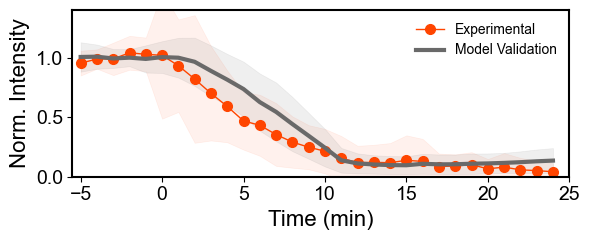

---------Summary: utag_c_free----------

----------Cells------------
total_cells:  24
number_of_responding_cells:  22
number_of_non_responding_cells:  2
percentage_non_responding_cells:  8.3

----------RNA------------
average_total_molecules_before_treatment:  535.0
average_molecules_before_treatment_responding:  500.8
average_molecules_before_treatment_non_responding:  34.2

--- Linear Fit Results for utag_c_free ---
Fit range: 0.0 to 12.0 min (HT to plateau)
Slope: -0.0762 ± 0.0032
Intercept: 1.0237
R-squared: 0.981
P-value: 8.41e-11
Run-off time: 13.4 min
Plots saved to: /Users/nzlab-la/Desktop/utag_paper/optimization/results_ACF


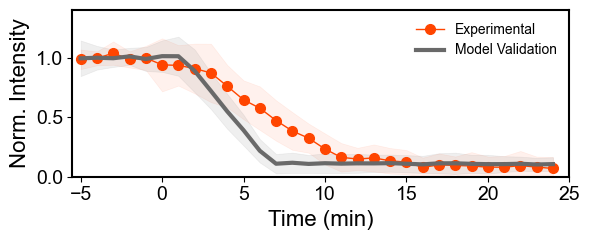

---------Summary: SunTag----------

----------Cells------------
total_cells:  33
number_of_responding_cells:  32
number_of_non_responding_cells:  1
percentage_non_responding_cells:  3.0

----------RNA------------
average_total_molecules_before_treatment:  432.99999999999994
average_molecules_before_treatment_responding:  427.2
average_molecules_before_treatment_non_responding:  5.8

--- Linear Fit Results for suntag ---
Fit range: 0.0 to 13.0 min (HT to plateau)
Slope: -0.0677 ± 0.0051
Intercept: 0.8461
R-squared: 0.937
P-value: 1.47e-08
Run-off time: 12.5 min
Plots saved to: /Users/nzlab-la/Desktop/utag_paper/optimization/results_ACF


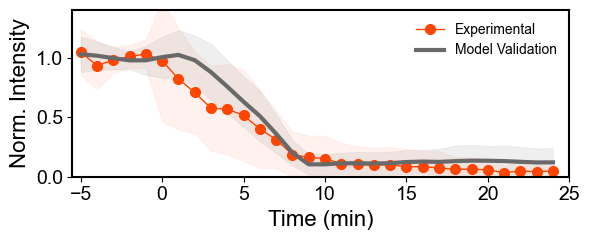

---------Summary: AlfaTag----------

----------Cells------------
total_cells:  32
number_of_responding_cells:  32
number_of_non_responding_cells:  0
percentage_non_responding_cells:  0.0

----------RNA------------
average_total_molecules_before_treatment:  401.2
average_molecules_before_treatment_responding:  401.2
average_molecules_before_treatment_non_responding:  0.0

--- Linear Fit Results for alfatag ---
Fit range: 0.0 to 13.0 min (HT to plateau)
Slope: -0.0812 ± 0.0040
Intercept: 1.0508
R-squared: 0.972
P-value: 1.04e-10
Run-off time: 12.9 min
Plots saved to: /Users/nzlab-la/Desktop/utag_paper/optimization/results_ACF


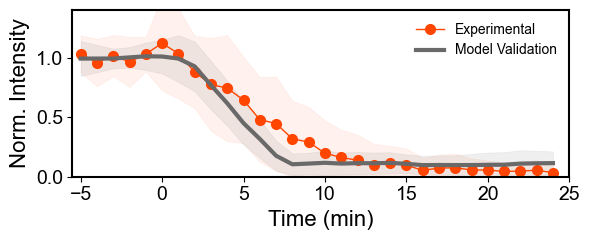

In [10]:
list_datasets = ['utag','utag_c_free','suntag','alfatag']
list_names = ['UTag', r'UTag($\Delta$C)', 'SunTag', 'ALFA-tag']
fig_size = (6, 2.5)

color_sim = 'dimgray'
color_exp = 'orangered'

RESPONSE_THRESHOLD = 0.3

for _, dataset_name in enumerate(list_datasets):
    process_HT_data (dataset_name,results_folder,harringtonine_frame=5,max_frame=30, plot_all_images= False,use_sem=False, show_individual_trajectories=False, show_summary=True,RESPONSE_THRESHOLD=RESPONSE_THRESHOLD,color_sim=color_sim, color_exp=color_exp,fig_size=fig_size)


# Optimization
___

In [ ]:

# def calculate_harringtonine_cost(experimental_data, simulated_data, experimental_error):
#     tiny = 1e-6
#     exp_error = experimental_error + tiny
#     return np.sum(((experimental_data - simulated_data) ** 2) / (exp_error ** 2))

def evaluate_harringtonine_ke_optimization(processed_data, results_folder, harringtonine_frame=5, 
                                          max_frame=30, number_elongation_rates=10, 
                                          inhibition_effectiveness=90, use_sem=False, 
                                          show_individual_trajectories=False, 
                                          color_sim='dimgray', color_exp='orangered', 
                                          fig_size=(6, 2.5), RESPONSE_THRESHOLD=0.2,
                                          ke_range=(1.5, 8.0),
                                          show_legend = False,
                                          fixed_ki=None,
                                          random_seed=REPRODUCIBLE_RANDOM_SEED,
                                          n_jobs=REPRODUCIBLE_N_JOBS):
    """
    Comprehensive function to evaluate multiple ke values for harringtonine data,
    find the best fit, and compare with original optimized parameters.
    
    Parameters:
    -----------
    ke_range : tuple
        Range of elongation rates to test (min_ke, max_ke) in aa/s
    random_seed : int
        Base seed used to derive deterministic seeds for each ke simulation batch.
    n_jobs : int
        Number of joblib workers. Deterministic because each repetition is seeded in its worker.
    """
    
    # Get dataset info and load data
    if processed_data == 'utag':
        results_dir = results_HT_data.joinpath('HT/Utag/HT_Analysis_GUI')
        plot_name = 'UTag'
    elif processed_data == 'utag_c_free':
        results_dir = results_HT_data.joinpath('HT/UTag_CF/HT_Analysis_GUI')
        plot_name = 'UTag_C_Free'
    elif processed_data == 'suntag':
        results_dir = results_HT_data.joinpath('HT/Suntag/HT_Analysis_GUI')
        plot_name = 'SunTag'
    elif processed_data == 'alfatag':
        results_dir = results_HT_data.joinpath('HT/ALFAtag/HT_Analysis_GUI')
        plot_name = 'AlfaTag'
    
    print(f"\n{'='*80}")
    print(f"COMPREHENSIVE KE OPTIMIZATION ANALYSIS FOR {plot_name}")
    print('='*80)
    
    # Load experimental data
    list_dataframes = []
    subfolders = [folder for folder in results_dir.iterdir() if folder.is_dir()]
    subfolders = [folder for folder in subfolders if 'results_' in folder.name]
    for subfolder in subfolders:
        files = [f for f in subfolder.iterdir() if f.is_file() and 'tracking_' in f.name and f.suffix == '.csv']
        if files:
            dfs = pd.read_csv(files[0])
            list_dataframes.append(dfs)
    
    # Process experimental data
    full_frames = np.arange(0, max_frame) 
    intensities_normalized = np.zeros((len(list_dataframes), len(full_frames)))
    
    for i, df in enumerate(list_dataframes):
        particle_counts_per_frame = df.groupby('frame')['particle'].nunique()
        sum_intensities_per_frame = df.groupby('frame')['spot_int_ch_0'].sum()
        particle_counts_per_frame = particle_counts_per_frame.reindex(full_frames, fill_value=0).values
        sum_intensities_per_frame = sum_intensities_per_frame.reindex(full_frames, fill_value=0).values
        
        if len(particle_counts_per_frame) > max_frame:
            particle_counts_per_frame = particle_counts_per_frame[:max_frame]
            sum_intensities_per_frame = sum_intensities_per_frame[:max_frame]
        
        intensities_normalized_before_treatment_intensity, _, _ = calculate_intensity(
            particle_counts_per_frame, sum_intensities_per_frame, harringtonine_frame)
        intensities_normalized[i] = intensities_normalized_before_treatment_intensity

    # Classify responding cells
    treatment_start_index = harringtonine_frame
    responding_indices = []
    for i, trajectory in enumerate(intensities_normalized):
        baseline = np.mean(trajectory[:treatment_start_index])
        threshold = RESPONSE_THRESHOLD * baseline
        avg_post_treatment = np.mean(trajectory[-5:])
        if avg_post_treatment < threshold:
            responding_indices.append(i)
    
    # Calculate experimental mean trajectory
    if responding_indices:
        mean_trajectory = np.mean(intensities_normalized[responding_indices, :], axis=0)
        std_trajectory = np.std(intensities_normalized[responding_indices, :], axis=0)
        if use_sem:
            err_trajectory = std_trajectory / np.sqrt(len(responding_indices))
        else:
            err_trajectory = std_trajectory
    else:
        print(" No responding cells found!")
        return None
    
    full_frames = (full_frames - harringtonine_frame)
    
    # Get original optimized parameters
    _, rna, first_probe_position_vector, gene_length, list_param = model_and_data_selection(processed_data)
    original_ki = list_param[0]
    original_ke = list_param[1]
    
    print(f" Experimental Data Summary:")
    print(f"   Total cells: {len(list_dataframes)}")
    print(f"   Responding cells: {len(responding_indices)} ({len(responding_indices)/len(list_dataframes)*100:.1f}%)")
    print(f"   Original optimized parameters:")
    print(f"      ki = {original_ki:.6f} 1/s")
    print(f"      ke = {original_ke:.3f} aa/s")
    
    # Define ke values to test
    list_elongation_rates = np.linspace(ke_range[0], ke_range[1], number_elongation_rates)
    
    # Simulation parameters
    harrintonine_delay_time_to_enter_cell = 0
    number_repetitions = 100
    burnin_time = 2000
    t_max = 60*max_frame # 30 minutes
    step_size_in_sec = 1
    time_array = np.arange(0, t_max, step_size_in_sec)
    timePerturbationApplication = harringtonine_frame*60 + harrintonine_delay_time_to_enter_cell
    evaluatingInhibitor = 1
 
    # Run simulations and calculate costs
    cost_results = []
    list_ssa_arrays = []
    list_err_ssa_arrays = []


    optimization_fixed_ki = fixed_ki if fixed_ki is not None else original_ki
    print(f"\n Running simulations with fixed ki = {optimization_fixed_ki:.6f} 1/s")
    print(f" Reproducible SSA mode: random_seed = {random_seed}, n_jobs = {n_jobs}")
    original_ki = optimization_fixed_ki
    
    for idx, ke_test in enumerate(list_elongation_rates):        
        simulation_seed = stable_seed(random_seed, processed_data, "ke_sweep", idx, f"{ke_test:.12g}")
        
        # Calculate codon-specific elongation rates
        ke = calculate_codon_elongation_rates(rna, global_elongation_rate=ke_test)
        # Run simulation
        ssa_array = simulate_TASEP_SSA_seeded_fast(
            original_ki,  # Use original optimized ki
            ke,
            gene_length, 
            t_max,
            time_interval_in_seconds=step_size_in_sec,
            number_repetitions=number_repetitions, 
            first_probe_position_vector=first_probe_position_vector, 
            timePerturbationApplication=timePerturbationApplication,
            inhibitor_effectiveness=inhibition_effectiveness,
            evaluatingInhibitor=evaluatingInhibitor,
            burnin_time=burnin_time,
            constant_elongation_rate=ke_test,
            fast_output=True,
            n_jobs=n_jobs,
            random_seed=simulation_seed,
            seed_context="rep",
            )[2]
        
        # Downsample and normalize
        time_array_downsampled = time_array[::60]
        ssa_array_downsampled = ssa_array[:,::60]
        time_array_min = time_array_downsampled/60
        
        normalized_data = np.zeros_like(ssa_array_downsampled)
        for i in range(ssa_array_downsampled.shape[0]):
            baseline_period = ssa_array_downsampled[i, :harringtonine_frame]
            mean_baseline = np.mean(baseline_period)
            if mean_baseline > 0:
                normalized_data[i] = ssa_array_downsampled[i] / mean_baseline
            else:
                normalized_data[i] = np.zeros_like(ssa_array_downsampled[i])
        
        mean_intensity_ssa_ht = np.mean(normalized_data, axis=0)
        if use_sem:
            err_intensity_ssa_ht = np.std(normalized_data, axis=0) / np.sqrt(normalized_data.shape[0])
        else:
            err_intensity_ssa_ht = np.std(normalized_data, axis=0)
        
        list_ssa_arrays.append(mean_intensity_ssa_ht)
        list_err_ssa_arrays.append(err_intensity_ssa_ht)
        
        sim_time = time_array_min - harringtonine_frame  

        # Define the comparison window more clearly
        exp_start_idx = harringtonine_frame  # Start comparing at drug application
        exp_end_idx = min(max_frame, len(mean_trajectory))  # Don't exceed data length
        
        # Extract experimental data for comparison window
        exp_data_cost = mean_trajectory[exp_start_idx:exp_end_idx]
        exp_error_cost = err_trajectory[exp_start_idx:exp_end_idx]
        
        # Interpolate simulation to match experimental time points
        # FIXED: Make sure we're interpolating at the right times
        #sim_data_cost = np.interp(exp_times_relative, sim_time, mean_intensity_ssa_ht)
        sim_data_cost = mean_intensity_ssa_ht[exp_start_idx:exp_end_idx]
        
        # Ensure arrays have same length (defensive programming)
        min_len = min(len(exp_data_cost), len(sim_data_cost))
        exp_data_cost = exp_data_cost[:min_len]
        sim_data_cost = sim_data_cost[:min_len]
        exp_error_cost = exp_error_cost[:min_len]
        
        # Calculate cost with small epsilon to avoid division by zero
        epsilon = 1e-6
        cost = np.sum(((exp_data_cost - sim_data_cost) ** 2) / (exp_error_cost ** 2 + epsilon))
        

        cost_results.append({
            'ke': ke_test,
            'cost': cost,
            'idx': idx,
            'mean_abs_diff': np.mean(np.abs(exp_data_cost - sim_data_cost))
        })
    
    # Find best fit
    if cost_results:
        cost_df = pd.DataFrame(cost_results)
        best_idx = cost_df['cost'].idxmin()
        best_ke = cost_df.loc[best_idx, 'ke']
        best_cost = cost_df.loc[best_idx, 'cost']
        best_sim_idx = cost_df.loc[best_idx, 'idx']
        best_mean_diff = cost_df.loc[best_idx, 'mean_abs_diff']
        
        # Find cost for original ke
        original_ke_closest_idx = np.argmin(np.abs(list_elongation_rates - original_ke))
        original_ke_tested = list_elongation_rates[original_ke_closest_idx]
        original_cost_row = cost_df[cost_df['idx'] == original_ke_closest_idx]
        
        if not original_cost_row.empty:
            original_cost = original_cost_row['cost'].iloc[0]
            original_mean_diff = original_cost_row['mean_abs_diff'].iloc[0]
        else:
            print("Could not find cost for original ke value")
            original_cost = None
            original_mean_diff = None
        
        # Print comprehensive results
        print(f"\n{'='*60}")
        print(f" OPTIMIZATION RESULTS FOR {plot_name}")
        print('='*60)
        print(f"BEST FIT PARAMETERS:")
        print(f"   ke_best = {best_ke:.3f} aa/s")
        print(f"   ki_fixed = {original_ki:.6f} 1/s")
        print(f"   Cost = {best_cost:.6f}")
        print(f"   Mean |difference| = {best_mean_diff:.4f}")
        
        print(f"\n ORIGINAL PARAMETERS:")
        print(f"   ke_original = {original_ke:.3f} aa/s")
        print(f"   ki_original = {original_ki:.6f} 1/s")
        if original_cost is not None:
            print(f"   Cost = {original_cost:.6f}")
            print(f"   Mean |difference| = {original_mean_diff:.4f}")
        
        print(f"\n COMPARISON:")
        print(f"   Δke = {best_ke - original_ke:.3f} aa/s ({((best_ke - original_ke)/original_ke)*100:+.1f}%)")
        if original_cost is not None:
            cost_improvement = original_cost - best_cost
            cost_improvement_pct = (cost_improvement / original_cost) * 100
            print(f"   ΔCost = {cost_improvement:.6f} ({cost_improvement_pct:+.2f}%)")
            
            if cost_improvement > 0:
                print(f"   Best fit is BETTER than original by {cost_improvement_pct:.2f}%")
            else:
                print(f"   Original parameters are BETTER by {-cost_improvement_pct:.2f}%")
        
        # Create the plot
        fig, ax = plt.subplots(figsize=fig_size, facecolor='white')
        ax.set_facecolor('white')
        
        # Plot individual trajectories if requested
        if show_individual_trajectories:
            for i in responding_indices:
                ax.plot(full_frames, intensities_normalized[i],
                        linestyle='-', color='dimgray', linewidth=0.2, alpha=0.3)
        
        # Plot experimental mean
        ax.plot(full_frames, mean_trajectory, 'o-', color=color_exp, linewidth=2, 
                label='Experimental Data', markersize=5)
        ax.fill_between(full_frames, mean_trajectory - err_trajectory, 
                       mean_trajectory + err_trajectory, color=color_exp, alpha=0.1)
        
        # Plot best fit simulation
        ax.plot(time_array_min-harringtonine_frame, list_ssa_arrays[best_sim_idx], '-',
                color=color_sim, linewidth=2, label=f'Model Fit')

        ax.axvspan(-1, 0, alpha=0.2, color='deepskyblue', zorder=0, label='HT Application')
        ax.set_xlabel("Time (min)", fontdict={'size': 16})
        ax.set_ylabel("Norm. Intensity", fontdict={'size': 16})
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)
        
        plt.ylim(0, 1.4)
        plt.xlim(-5.5, 25)
        if show_legend == True:
            ax.legend(fontsize=10, frameon=False, loc='upper right')
        ax.grid(False)
        plt.tight_layout()
        
        # Save plot and data
        plt.savefig(results_HT_plots.joinpath(f'HT_{plot_name}_ke_optimization.png'), 
                    dpi=600, bbox_inches='tight')
        plt.savefig(results_HT_plots.joinpath(f'HT_{plot_name}_ke_optimization.svg'), 
                    dpi=600, bbox_inches='tight')
        
        # Save cost analysis
        cost_file = results_HT_plots / f'ke_optimization_analysis_{plot_name}.csv'
        cost_df.to_csv(cost_file, index=False)
        
        plt.show()
        
        return {
            'cost_df': cost_df,
            'best_ke': best_ke,
            'best_cost': best_cost,
            'original_ke': original_ke,
            'original_cost': original_cost,
            'plot_name': plot_name,
            'responding_cells': len(responding_indices),
            'total_cells': len(list_dataframes)
        }
    
    else:
        print(" No valid cost calculations performed")
        return None

STARTING COMPREHENSIVE KE OPTIMIZATION ANALYSIS

COMPREHENSIVE KE OPTIMIZATION ANALYSIS FOR UTag
 Experimental Data Summary:
   Total cells: 38
   Responding cells: 32 (84.2%)
   Original optimized parameters:
      ki = 0.031266 1/s
      ke = 3.114 aa/s

 Running simulations with fixed ki = 0.030000 1/s
 Reproducible SSA mode: random_seed = 42, n_jobs = -1

 OPTIMIZATION RESULTS FOR UTag
BEST FIT PARAMETERS:
   ke_best = 3.500 aa/s
   ki_fixed = 0.030000 1/s
   Cost = 3.372887
   Mean |difference| = 0.0598

 ORIGINAL PARAMETERS:
   ke_original = 3.114 aa/s
   ki_original = 0.030000 1/s
   Cost = 3.383385
   Mean |difference| = 0.0669

 COMPARISON:
   Δke = 0.386 aa/s (+12.4%)
   ΔCost = 0.010498 (+0.31%)
   Best fit is BETTER than original by 0.31%


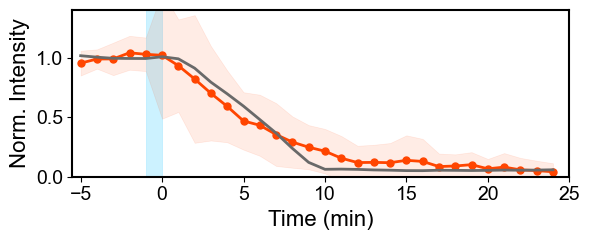


COMPREHENSIVE KE OPTIMIZATION ANALYSIS FOR UTag_C_Free
 Experimental Data Summary:
   Total cells: 24
   Responding cells: 22 (91.7%)
   Original optimized parameters:
      ki = 0.063165 1/s
      ke = 5.291 aa/s

 Running simulations with fixed ki = 0.030000 1/s
 Reproducible SSA mode: random_seed = 42, n_jobs = -1

 OPTIMIZATION RESULTS FOR UTag_C_Free
BEST FIT PARAMETERS:
   ke_best = 3.000 aa/s
   ki_fixed = 0.030000 1/s
   Cost = 4.586964
   Mean |difference| = 0.0399

 ORIGINAL PARAMETERS:
   ke_original = 5.291 aa/s
   ki_original = 0.030000 1/s
   Cost = 41.508234
   Mean |difference| = 0.1471

 COMPARISON:
   Δke = -2.291 aa/s (-43.3%)
   ΔCost = 36.921270 (+88.95%)
   Best fit is BETTER than original by 88.95%


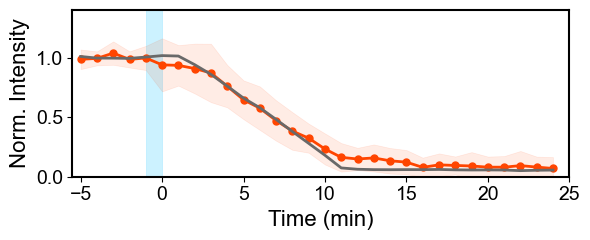


COMPREHENSIVE KE OPTIMIZATION ANALYSIS FOR SunTag
 Experimental Data Summary:
   Total cells: 33
   Responding cells: 32 (97.0%)
   Original optimized parameters:
      ki = 0.033924 1/s
      ke = 4.329 aa/s

 Running simulations with fixed ki = 0.030000 1/s
 Reproducible SSA mode: random_seed = 42, n_jobs = -1

 OPTIMIZATION RESULTS FOR SunTag
BEST FIT PARAMETERS:
   ke_best = 4.000 aa/s
   ki_fixed = 0.030000 1/s
   Cost = 2.286218
   Mean |difference| = 0.0546

 ORIGINAL PARAMETERS:
   ke_original = 4.329 aa/s
   ki_original = 0.030000 1/s
   Cost = 3.066779
   Mean |difference| = 0.0653

 COMPARISON:
   Δke = -0.329 aa/s (-7.6%)
   ΔCost = 0.780561 (+25.45%)
   Best fit is BETTER than original by 25.45%


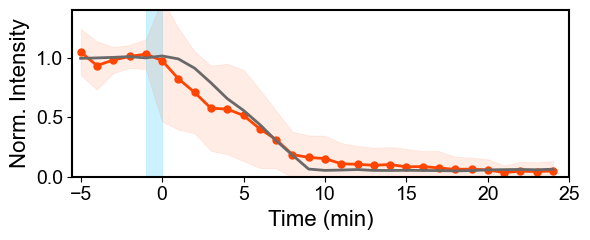


COMPREHENSIVE KE OPTIMIZATION ANALYSIS FOR AlfaTag
 Experimental Data Summary:
   Total cells: 32
   Responding cells: 32 (100.0%)
   Original optimized parameters:
      ki = 0.042785 1/s
      ke = 4.835 aa/s

 Running simulations with fixed ki = 0.030000 1/s
 Reproducible SSA mode: random_seed = 42, n_jobs = -1

 OPTIMIZATION RESULTS FOR AlfaTag
BEST FIT PARAMETERS:
   ke_best = 3.000 aa/s
   ki_fixed = 0.030000 1/s
   Cost = 1.688725
   Mean |difference| = 0.0467

 ORIGINAL PARAMETERS:
   ke_original = 4.835 aa/s
   ki_original = 0.030000 1/s
   Cost = 5.525844
   Mean |difference| = 0.1017

 COMPARISON:
   Δke = -1.835 aa/s (-38.0%)
   ΔCost = 3.837119 (+69.44%)
   Best fit is BETTER than original by 69.44%


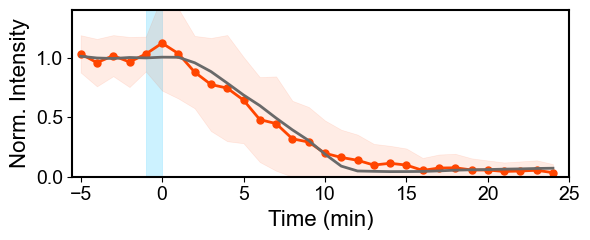


SUMMARY COMPARISON ACROSS ALL DATASETS

UTag:
   Best ke: 3.500 vs Original: 3.114 (+12.4%)
   Cost improvement: +0.31%
   Responding cells: 32/38

UTag_C_Free:
   Best ke: 3.000 vs Original: 5.291 (-43.3%)
   Cost improvement: +88.95%
   Responding cells: 22/24

SunTag:
   Best ke: 4.000 vs Original: 4.329 (-7.6%)
   Cost improvement: +25.45%
   Responding cells: 32/33

AlfaTag:
   Best ke: 3.000 vs Original: 4.835 (-38.0%)
   Cost improvement: +69.44%
   Responding cells: 32/32


In [12]:
seed_all_rngs(REPRODUCIBLE_RANDOM_SEED)
list_datasets = ['utag', 'utag_c_free', 'suntag', 'alfatag']
optimization_results = {}
print("STARTING COMPREHENSIVE KE OPTIMIZATION ANALYSIS")
print("="*80)
for dataset_name in list_datasets:
    result = evaluate_harringtonine_ke_optimization(
        processed_data=dataset_name,
        results_folder=results_folder,
        harringtonine_frame=5, # Frame when harringtonine was applied
        max_frame=30,
        number_elongation_rates=15,  # Higher resolution
        inhibition_effectiveness=95,
        use_sem=False,
        show_individual_trajectories=False,
        color_sim='dimgray',
        color_exp='orangered',
        fig_size = (6, 2.5),
        RESPONSE_THRESHOLD=RESPONSE_THRESHOLD,
        ke_range=(1.0, 8.0),  # Wide range to test
        fixed_ki=0.03,  # Fix ki to original optimized value
        random_seed=REPRODUCIBLE_RANDOM_SEED,
        n_jobs=REPRODUCIBLE_N_JOBS
    )
    
    if result:
        optimization_results[dataset_name] = result

# Summary comparison across all datasets
print(f"\n{'='*80}")
print("SUMMARY COMPARISON ACROSS ALL DATASETS")
print('='*80)

for dataset, result in optimization_results.items():
    improvement = ((result['original_cost'] - result['best_cost']) / result['original_cost']) * 100
    ke_change = ((result['best_ke'] - result['original_ke']) / result['original_ke']) * 100
    
    print(f"\n{result['plot_name']}:")
    print(f"   Best ke: {result['best_ke']:.3f} vs Original: {result['original_ke']:.3f} ({ke_change:+.1f}%)")
    print(f"   Cost improvement: {improvement:+.2f}%")
    print(f"   Responding cells: {result['responding_cells']}/{result['total_cells']}")